## **1. Introduction**
The goal of this notebook is to estimate a CNN model

## **2. Libraries**

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# Standard
import os
import sys
import warnings
import pandas as pd
import numpy as np

# Image
import cv2
from PIL import Image
import matplotlib.pyplot as plt

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, roc_auc_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# Tensor Flow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


from tqdm.auto import tqdm

# Local Modules
sys.path.append('/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/utils')
from cnn_utils import (
    load_images,
    get_class_weights,
    build_model,
    train_model,
    plot_history,
    load_trained_model,
    predict_test
)
import cfg_cnn  as cfg
warnings.filterwarnings('ignore')


## **3. Utils**

In [13]:
def image_path_generation(row, base_path='/wmdd811k/images'):
    """
    Generate the full path to an image based on the dataset split and image name.

    Parameters:
    - row (pd.Series): A row with at least 'set' and 'image' fields.
    - base_path (str): The base directory containing the image folders.

    Returns:
    - str: Full path to the image file.
    """
    subfolder = row['set']
    return os.path.join(base_path, subfolder, row['image'])

# Define function to compute ROC AUC score per class in a one-vs-all manner
def roc_auc_score_multiclass(actual_class, pred_class):
    unique_classes = set(actual_class)
    roc_auc_dict = {}
    for cls in unique_classes:
        binary_actual = [1 if x == cls else 0 for x in actual_class]
        binary_pred = [1 if x == cls else 0 for x in pred_class]
        try:
            roc_auc = roc_auc_score(binary_actual, binary_pred)
        except ValueError:
            roc_auc = float('nan')  # Handle case with no positive samples
        roc_auc_dict[cls] = roc_auc
    return roc_auc_dict



## **4. Load data and split data**

In [14]:
# Define the base path for images
dataseet_path = '/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/dataset/'
file_name = 'WM_811k_subset.csv'

# Load dataset
df = pd.read_csv(dataseet_path + file_name, index_col=0)

# Generate full image paths by passing base_image_path to the function via lambda
df['image_id'] = df.apply(lambda row: image_path_generation(row, base_path=dataseet_path), axis=1)

df.shape

(10860, 7)

In [15]:
# Split the main DataFrame into separate datasets: train, val, test
datasets = {}
for split in ['train', 'val', 'test']:
    subset = df[df['set'] == split].reset_index(drop=True)
    datasets[split] = subset
    print(f"{split} shape: {subset.shape}")

# Assign individual datasets for easier access
train = datasets['train']
valid = datasets['val']
test = datasets['test']

# Drop unnecessary columns from each dataset
cols_to_drop = ['wf_id', 'dieSize', 'lotid', 'image', 'set']
train = train.drop(cols_to_drop, axis=1)
valid = valid.drop(cols_to_drop, axis=1)
test = test.drop(cols_to_drop, axis=1)

train shape: (5907, 7)
val shape: (1304, 7)
test shape: (2172, 7)


In [16]:
# labels encoding
label2int = {
    'Center': 0,
     'Donut': 1,
     'Edge-Loc': 2,
     'Edge-Ring': 3,
     'Loc': 4,
     'Random': 5,
     'Scratch': 6,
     'Near-full': 7}

train['labels']=train.labels.map(label2int)
valid['labels']=valid.labels.map(label2int)
test['labels']=test.labels.map(label2int)

print(np.sort(train['labels'].unique()))
print(np.sort(valid['labels'].unique()))
print(np.sort(test['labels'].unique()))

[0 1 2 3 4 5 6 7]
[0 1 2 3 4 5 6 7]
[0 1 2 3 4 5 6 7]


<class 'numpy.ndarray'>
(404, 404, 3)
<class 'numpy.ndarray'>
(404, 404, 3)


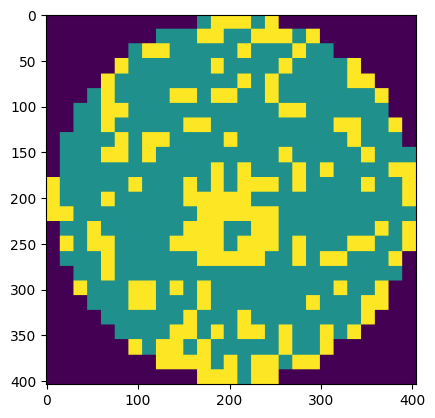

In [17]:
# Image preview check
sample_image = cv2.imread(train.iloc[0]['image_id'])
print(type(sample_image))
print(sample_image.shape)
sample_image = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)
print(type(sample_image))
print(sample_image.shape)
plt.imshow(sample_image)

## **5. Build and compile model**

In [18]:
model = build_model(cfg.input_shape, cfg.num_classes)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # accepts integer labels
    metrics=['accuracy']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 51, 51, 64)     │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 51, 51, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,514,440 (13.41 MB)

 Trainable params: 3,512,776 (13.40 MB)

 Non-trainable params: 1,664 (6.50 KB)

## **6. Train model**

In [19]:
(X_train, y_train) = load_images(train,cfg)
(X_val, y_val) = load_images(valid,cfg)
print('X train lenght:', len(X_train))
print('Y train lenght:', len(y_train))
print('X valid lenght:', len(X_val))
print('Y valid lenght:', len(y_val))

Loading images: 100%|██████████| 1304/1304 [00:12<00:00, 102.86it/s]

X train lenght: 5907
Y train lenght: 5907
X valid lenght: 1304
Y valid lenght: 1304


In [ ]:
train_model(model, X_train, y_train, X_val, y_val, cfg, use_class_weights=True)

Epoch 1/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 315s 3s/step - accuracy: 0.1229 - loss: 5.3072 - val_accuracy: 0.3811 - val_loss: 2.9525
Epoch 2/200
24/93 ━━━━━━━━━━━━━━━━━━━━ 3:34 3s/step - accuracy: 0.0395 - loss: 2.0005

## **Test evaluation**

In [23]:
model_dir = '/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/models/'
model_name ='CNN_best_model.keras'

# Carica il modello
model = load_trained_model(model_dir,model_name)

test_predictions = predict_test(model, test, cfg)


Model successfully loaded from /content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/models/CNN_best_model.keras


Predicting:   1%|▌                                               | 26/2172 [00:00<00:19, 109.15it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 977ms/step


Predicting:   3%|█▎                                               | 59/2172 [00:01<01:05, 32.50it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step


Predicting:  99%|██████████████████████████████████████████████▎| 2143/2172 [07:18<00:06,  4.71it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step


Predicting: 100%|███████████████████████████████████████████████| 2172/2172 [07:26<00:00,  4.86it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 935ms/step


In [27]:
# Add predictions to the test DataFrame
test['preds'] = test_predictions

# Extract class labels and their corresponding IDs
labels = list(label2int.keys())
labels_id = list(label2int.values())
#print("Label IDs:", labels_id)

# Ground truth and predicted labels
y_true = test['labels']
y_pred = test['preds']

# Print overall accuracy and macro F1-score
print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.3f}")
print(f"Macro F1 Score: {f1_score(y_true, y_pred, average='macro'):.3f}")

# Labeling
#----------------------------------------------------------------------------------
labels = list(label2int.keys())
int2label = {v: k for k, v in label2int.items()}


# Compute ROC AUC per class and map them to their labels
roc_auc_raw = roc_auc_score_multiclass(y_true, y_pred)
roc_auc_named = {int2label[k]: round(v, 2) for k, v in roc_auc_raw.items()}

# Print ROC AUC scores for each class
print('----------------------------------------')
print("ROC AUC for each class:")
for label, score in roc_auc_named.items():
    print(f"{label}: {score}")

# Optional: print label names
#print("Labels:", labels)

Overall Accuracy: 0.903
Macro F1 Score: 0.855
----------------------------------------
ROC AUC for each class:
Center: 0.97
Donut: 0.97
Edge-Loc: 0.9
Edge-Ring: 0.98
Loc: 0.89
Random: 0.9
Scratch: 0.89
Near-full: 1.0
